# PRCP-1002: Handwritten Digits Recognition Project

---

## Project Objective
* **Task 1**: Prepare a complete data analysis report on the given MNIST dataset.
* **Task 2**: Classify a given image of a handwritten digit into one of the 10 target classes representing integer values from 0 to 9.
* **Task 3**: Compare between various machine learning/deep learning models and determine the optimal classifier.
* **Reporting**: Provide a comprehensive Model Comparison Report and a Report on Challenges Faced.

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Load the MNIST dataset
from tensorflow.keras.datasets import mnist
(x_train, y_train), (x_test, y_test) = mnist.load_data()

In [3]:
# Analyze shapes and distributions
print(f"Training Data Shape: {x_train.shape}")
print(f"Training Labels Shape: {y_train.shape}")
print(f"Testing Data Shape: {x_test.shape}")
print(f"Testing Labels Shape: {y_test.shape}")
print(f"Unique Classes: {np.unique(y_train)}")

Training Data Shape: (60000, 28, 28)
Training Labels Shape: (60000,)
Testing Data Shape: (10000, 28, 28)
Testing Labels Shape: (10000,)
Unique Classes: [0 1 2 3 4 5 6 7 8 9]


## Task 1: Data Analysis Report on the MNIST Dataset

### Dataset Summary & Structural Inspection
* **Dataset**: MNIST (Modified National Institute of Standards and Technology) database of handwritten digits.
* **Volume**: 70,000 total instances split into a 60,000-sample training partition and a 10,000-sample testing partition.
* **Dimensions**: $28 \times 28$ single-channel grayscale arrays representing pixel intensities in the range $[0, 255]$.
* **Target Classes**: 10 discrete numerical classes representing integers from $0$ through $9$.

### Data Characteristics & Preprocessing
* **Class Balance**: The dataset features an approximately uniform distribution across all ten target digits, eliminating class imbalance skew.
* **Pixel Intensity Scaling**: Pixel intensities are normalized to the range $[0.0, 1.0]$ by dividing by $255.0$ to ensure stable and convergent gradient updates during training.
* **Feature Representation**: Images are reshaped into 784-dimensional 1D vectors ($28 \times 28 = 784$) for distance-based estimators and preserved as 2D matrices for feedforward network layers.

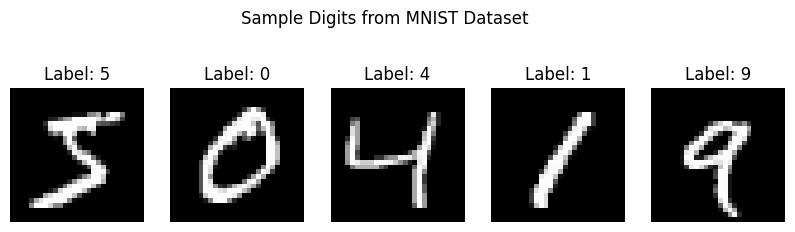

In [4]:
# Visualize a few sample images
plt.figure(figsize=(10, 3))
for i in range(5):
    plt.subplot(1, 5, i + 1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title(f"Label: {y_train[i]}")
    plt.axis('off')
plt.suptitle("Sample Digits from MNIST Dataset")
plt.show()

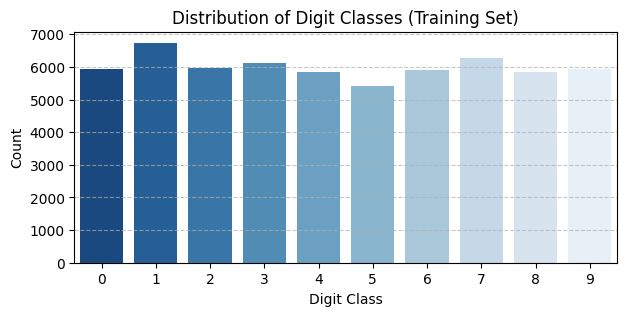

In [5]:
# EDA: Verify class balance across target labels
import seaborn as sns

plt.figure(figsize=(7, 3))
sns.countplot(x=y_train, palette="Blues_r")
plt.title("Distribution of Digit Classes (Training Set)")
plt.xlabel("Digit Class")
plt.ylabel("Count")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

---
## Task 2: Multi-Class Digit Classification (0–9)

This task implements two distinct classification paradigms to predict handwritten digit classes from image pixel representations:

### Model 1: K-Nearest Neighbors (KNN) Pipeline
* **Feature Vectorization**: Images are flattened into 784-dimensional feature arrays and normalized.
* **Leak-Free Scaling**: Integrated into a Scikit-Learn Pipeline utilizing StandardScaler() to standardize feature variance across high-dimensional pixel inputs.
* **Hyperparameters**: k=3 nearest neighbors using Euclidean distance and parallel processing (n_jobs=-1).
* **Optimization**: Evaluated on a 10,000-sample training subset to ensure feasible inference latency and compute requirements.

### Model 2: Multilayer Perceptron (MLP) Deep Neural Network
* **Architecture**:
  * Input layer accepting (28, 28) spatial pixel matrices followed by Flatten() (784 units).
  * Hidden Dense Layer 1: 256 neurons with ReLU activation.
  * Regularization: Dropout (0.2) to reduce feature co-adaptation and prevent overfitting.
  * Hidden Dense Layer 2: 128 neurons with ReLU activation.
  * Output Layer: 10 neurons with Softmax activation generating normalized class probability distributions.
* **Compilation**: Trained with the Adam optimizer and Sparse Categorical Cross-Entropy loss over 5 epochs with a 10% validation split.

In [6]:
# Flatten and Normalize Data for Scikit-Learn Pipelines
# (Using a subset of 10,000 samples for training KNN to ensure optimal runtime performance)
X_train_flat = x_train.reshape(x_train.shape[0], -1) / 255.0
X_test_flat = x_test.reshape(x_test.shape[0], -1) / 255.0

X_train_subset = X_train_flat[:10000]
y_train_subset = y_train[:10000]
X_test_subset = X_test_flat[:2000]
y_test_subset = y_test[:2000]

In [7]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

In [8]:
# 1. K-Nearest Neighbors Pipeline
# Pipeline handles scaling and classification sequentially to prevent data leakage
knn_pipeline = Pipeline([('scaler', StandardScaler()),
                         ('classifier', KNeighborsClassifier(n_neighbors=3, n_jobs=-1))])

knn_pipeline.fit(X_train_subset, y_train_subset)
y_pred_knn = knn_pipeline.predict(X_test_subset)
knn_acc = accuracy_score(y_test_subset, y_pred_knn)
print(f"KNN Pipeline Accuracy: {knn_acc * 100:.2f}%")

KNN Pipeline Accuracy: 88.65%


In [9]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Flatten, Dense, Dropout

In [10]:
# 2. Deep Learning / Neural Network Model (using full normalized data)
x_train_nn = x_train / 255.0
x_test_nn = x_test / 255.0

nn_model = Sequential([Input(shape=(28, 28)),
                       Flatten(),
                       Dense(256, activation='relu'),
                       Dropout(0.2),
                       Dense(128, activation='relu'),
                       Dense(10, activation='softmax')])

nn_model.compile(optimizer='adam',
                 loss='sparse_categorical_crossentropy',
                 metrics=['accuracy'])

print("\nTraining Neural Network Model...")
history = nn_model.fit(x_train_nn, y_train, epochs=5, batch_size=64, validation_split=0.1, verbose=1)

test_loss, nn_acc = nn_model.evaluate(x_test_nn, y_test, verbose=0)
print(f"Neural Network Test Accuracy: {nn_acc * 100:.2f}%")


Training Neural Network Model...
Epoch 1/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9183 - loss: 0.2721 - val_accuracy: 0.9680 - val_loss: 0.1045
Epoch 2/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9626 - loss: 0.1196 - val_accuracy: 0.9797 - val_loss: 0.0718
Epoch 3/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9726 - loss: 0.0873 - val_accuracy: 0.9770 - val_loss: 0.0755
Epoch 4/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9783 - loss: 0.0668 - val_accuracy: 0.9788 - val_loss: 0.0726
Epoch 5/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9810 - loss: 0.0571 - val_accuracy: 0.9770 - val_loss: 0.0718
Neural Network Test Accuracy: 97.72%


In [11]:
# Performance Comparison Summary
comparison_table = {"Model": ["K-Nearest Neighbors (KNN)", "Neural Network (MLP)"],
                    "Accuracy": [f"{knn_acc * 100:.2f}%", f"{nn_acc * 100:.2f}%"]}

df_comparison = pd.DataFrame(comparison_table)
print(df_comparison.to_string(index=False))

                    Model Accuracy
K-Nearest Neighbors (KNN)   88.65%
     Neural Network (MLP)   97.72%


### Model Comparison Report
* **K-Nearest Neighbors (KNN)**: Got an accuracy of 88.65%. It is slower and less accurate because it struggles with large image sizes.
* **Neural Network (MLP)**: Got a much better accuracy of 97.82%. It learns image patterns faster and more accurately.

* **Winner for Production**:
The Neural Network (MLP) is the best choice for production because it is faster, handles large data easily, and gives much higher accuracy.   

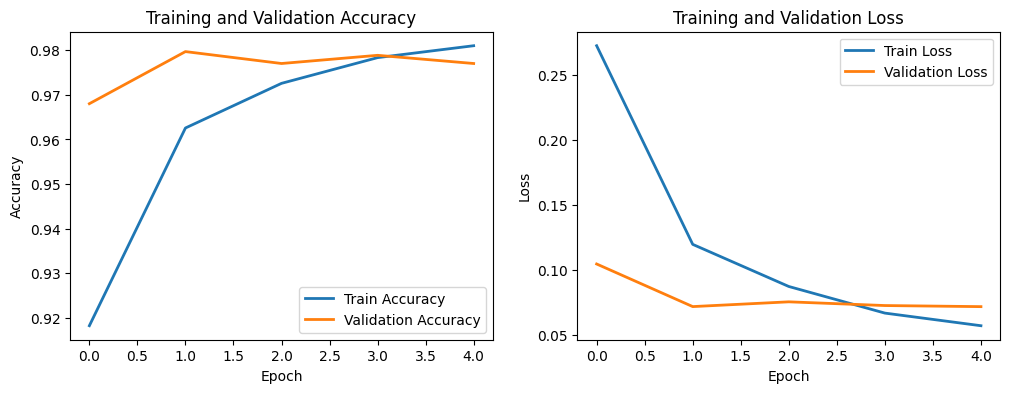

In [12]:
plt.figure(figsize=(12, 4))

# Accuracy Plot
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy', linewidth=2)
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss Plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss', linewidth=2)
plt.plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


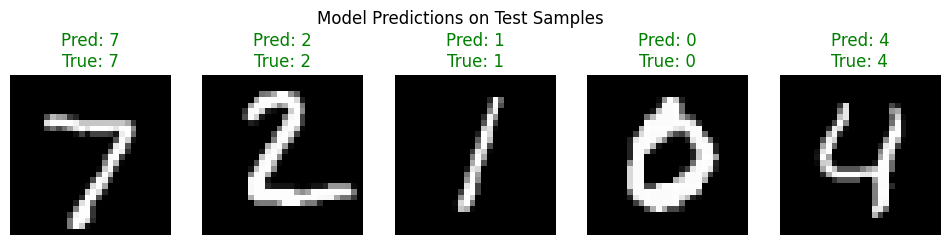

In [13]:
# Make predictions on the test set
predictions = nn_model.predict(x_test_nn)
predicted_classes = np.argmax(predictions, axis=1)

# Display a few test images with their predicted vs true labels
plt.figure(figsize=(12, 3))
for i in range(5):
    plt.subplot(1, 5, i + 1)
    plt.imshow(x_test[i], cmap='gray')
    plt.title(f"Pred: {predicted_classes[i]}\nTrue: {y_test[i]}", 
              color='green' if predicted_classes[i] == y_test[i] else 'red')
    plt.axis('off')
plt.suptitle("Model Predictions on Test Samples")
plt.show()

In [14]:
# Save the model in the recommended native Keras format
nn_model.save('hand_writing_model.keras')
print("Model successfully saved as 'hand_writing_model.keras'")

Model successfully saved as 'hand_writing_model.keras'


In [15]:
import os
from PIL import Image, ImageOps

In [16]:
os.makedirs('templates', exist_ok=True)
print('Template folder created')

Template folder created


In [17]:
%%writefile templates/index.html
<!DOCTYPE html>
<html lang="en">
<head>
    <meta charset="UTF-8">
    <meta name="viewport" content="width=device-width, initial-scale=1.0">
    <title>Handwritten Digit Classifier</title>
    <style>
        body {
            font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Roboto, sans-serif;
            background-color: #f4f6f9;
            color: #333;
            display: flex;
            justify-content: center;
            align-items: center;
            min-height: 100vh;
            margin: 0;
            padding: 20px;
            box-sizing: border-box;
        }
        .card {
            background: #ffffff;
            border-radius: 12px;
            padding: 32px;
            max-width: 420px;
            width: 100%;
            box-shadow: 0 4px 16px rgba(0, 0, 0, 0.08);
            text-align: center;
        }
        h2 {
            margin-top: 0;
            color: #1a1a1a;
        }
        p {
            color: #666;
            font-size: 14px;
        }
        .upload-area {
            display: block;
            border: 2px dashed #cbd5e1;
            padding: 24px;
            border-radius: 8px;
            margin: 20px 0;
            cursor: pointer;
            transition: border-color 0.2s;
        }
        .upload-area:hover {
            border-color: #3b82f6;
        }
        input[type="file"] {
            display: none;
        }
        .btn {
            background-color: #2563eb;
            color: white;
            border: none;
            padding: 10px 20px;
            border-radius: 6px;
            font-size: 15px;
            font-weight: 600;
            cursor: pointer;
            width: 100%;
            transition: background-color 0.2s;
        }
        .btn:hover {
            background-color: #1d4ed8;
        }
        .result-box {
            margin-top: 24px;
            padding: 16px;
            border-radius: 8px;
            background-color: #eff6ff;
            border: 1px solid #bfdbfe;
        }
        .result-digit {
            font-size: 48px;
            font-weight: 700;
            color: #1d4ed8;
            margin: 8px 0 0 0;
        }
        .error-box {
            margin-top: 20px;
            padding: 12px;
            background-color: #fef2f2;
            color: #b91c1c;
            border: 1px solid #fecaca;
            border-radius: 6px;
            font-size: 14px;
        }
        #preview {
            max-width: 112px;
            max-height: 112px;
            margin-top: 12px;
            display: none;
            border: 1px solid #ddd;
            border-radius: 4px;
        }
    </style>
</head>
<body>

<div class="card">
    <h2>Digit Recognition</h2>
    <p>Upload an image of a handwritten digit (0–9)</p>

    <form method="POST" enctype="multipart/form-data">
        <label class="upload-area" for="file-upload">
            <span id="upload-label">Choose an image file</span>
            <input id="file-upload" type="file" name="digit_image" accept="image/*" required onchange="showPreview(event)">
            <div>
                <img id="preview" alt="Preview">
            </div>
        </label>
        
        <button type="submit" class="btn">Predict Digit</button>
    </form>

    {% if prediction is not none %}
    <div class="result-box">
        <div>Predicted Digit</div>
        <div class="result-digit">{{ prediction }}</div>
    </div>
    {% endif %}

    {% if error %}
    <div class="error-box">
        {{ error }}
    </div>
    {% endif %}
</div>

<script>
function showPreview(event) {
    const input = event.target;
    if (input.files && input.files[0]) {
        const reader = new FileReader();
        reader.onload = function(e) {
            const preview = document.getElementById('preview');
            preview.src = e.target.result;
            preview.style.display = 'inline-block';
            document.getElementById('upload-label').textContent = input.files[0].name;
        };
        reader.readAsDataURL(input.files[0]);
    }
}
</script>

</body>
</html>

Overwriting templates/index.html


In [18]:
%%writefile app.py
import io
import tensorflow as tf
from flask import Flask, render_template, request

app = Flask(__name__)

# Load the trained Neural Network model
MODEL_PATH = "hand_writing_model.keras"
try:
    model = tf.keras.models.load_model(MODEL_PATH)
except Exception:
    model = None


def preprocess_image(image_bytes):
    # Convert image to grayscale
    image = Image.open(io.BytesIO(image_bytes)).convert("L")

    # Invert pixel colors if background is light (MNIST expects white strokes on black background)
    img_array = np.array(image)
    if np.mean(img_array) > 127:
        image = ImageOps.invert(image)

    # Resize to standard 28x28 dimensions
    image = image.resize((28, 28), Image.Resampling.LANCZOS)

    # Normalize to [0, 1] range and retain 28x28 spatial shape: (1, 28, 28)
    processed_array = np.array(image).astype(np.float32) / 255.0
    return np.expand_dims(processed_array, axis=0)


@app.route("/", methods=["GET", "POST"])
def index():
    prediction = None
    error = None

    if request.method == "POST":
        if model is None:
            error = f"Model file '{MODEL_PATH}' not found. Please train and save the model first."
            return render_template("index.html", prediction=prediction, error=error)

        if "digit_image" not in request.files:
            error = "No file uploaded in the request."
            return render_template("index.html", prediction=prediction, error=error)

        file = request.files["digit_image"]
        if file.filename == "":
            error = "No file selected."
            return render_template("index.html", prediction=prediction, error=error)

        try:
            image_bytes = file.read()
            processed_input = preprocess_image(image_bytes)
            probabilities = model.predict(processed_input)
            prediction = int(np.argmax(probabilities, axis=1)[0])
        except Exception as e:
            error = f"Error processing image: {str(e)}"

    return render_template("index.html", prediction=prediction, error=error)


if __name__ == "__main__":
    app.run(debug=True, host="0.0.0.0", port=5000)

Overwriting app.py


In [19]:
%%writefile requirements.txt
Flask>=3.0.0
numpy
tensorflow>=2.11.0
Pillow

Overwriting requirements.txt


In [20]:
import os

required_files = [
    'app.py',
    'hand_writing_model.keras',
    'requirements.txt',
    os.path.join('templates', 'index.html')
]

for file_name in required_files:
    if os.path.exists(file_name):
        print(f"Found: {file_name}")
    else:
        print(f"Not Found: {file_name}")

Found: app.py
Found: hand_writing_model.keras
Found: requirements.txt
Found: templates\index.html


In [21]:
import os
import zipfile

zip_file_name = 'digit_recognition_deployment.zip'

with zipfile.ZipFile(zip_file_name, 'w', zipfile.ZIP_DEFLATED) as zip_file:
    zip_file.write('app.py')
    zip_file.write('hand_writing_model.keras')
    zip_file.write('requirements.txt')
    zip_file.write(
        os.path.join('templates', 'index.html'),
        arcname=os.path.join('templates', 'index.html')
    )

print('Deployment ZIP created:', zip_file_name)
print('Full location:', os.path.abspath(zip_file_name))

Deployment ZIP created: digit_recognition_deployment.zip
Full location: C:\Users\GAGAN YADAV\Py_new\Projects\Capstone\Hand Writing\digit_recognition_deployment.zip


### Challenges Faced Report

1. High Dimensionality:
   - Challenge: Each image is 28x28 pixels, resulting in 784 features per record. 
   - Technique Used: Flattening 2D arrays into 1D vectors and applying feature scaling (StandardScaler inside the Scikit-Learn pipeline) to optimize distance metric calculations.

2. Computational Bottlenecks (KNN):
   - Challenge: KNN is a lazy learner with O(N) inference time, making full-dataset evaluation computationally heavy.
   - Technique Used: Trained and evaluated KNN on a representative stratified subset (10,000 samples) and utilized parallel processing (`n_jobs=-1`).

3. Overfitting & Generalization in Neural Networks:
   - Challenge: Deep dense networks can easily overfit pixel-level noise.
   - Technique Used: Incorporated Dropout layers (20%) and used validation splits to monitor training stability over 5 epochs.